✓ Loaded 14 cohorts with condition info

✓ Loaded 39 sessions

Condition breakdown:
  emotion recipe  phase_sequence  n
Emotional  Apple emotional_first  5
Emotional  Apple   neutral_first  4
Emotional Banana emotional_first  7
Emotional Banana   neutral_first  3
  Neutral  Apple emotional_first  7
  Neutral  Apple   neutral_first  4
  Neutral Banana emotional_first  6
  Neutral Banana   neutral_first  3

Unique participants in analysis : 43
Total dyads                     : 39

ANALYSIS 1: HR SYNCHRONY (Fisher Z) — EMOTIONAL vs NEUTRAL

Mean synchrony (Fisher Z) by condition:
                  Mean Fisher Z        SD   N
emotion   recipe                             
Emotional Apple        0.088975  0.173921   9
          Banana       0.136961  0.124685  10
Neutral   Apple       -0.054730  0.101694  11
          Banana       0.138802  0.079796   9

ANOVA on HR synchrony:
                        sum_sq    df         F    PR(>F)  partial_eta_sq
C(emotion)            0.050964   1.0  3.326

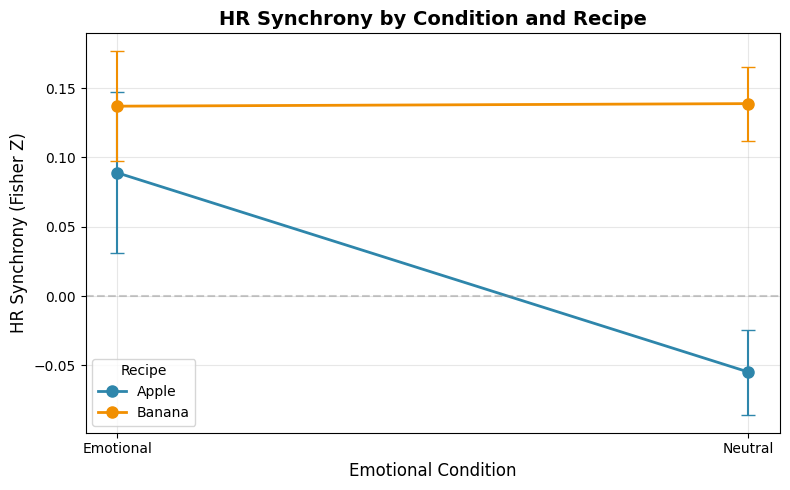

✓ Saved analysis1_hr_synchrony.png

ANALYSIS 2: INDIVIDUAL HR — EMOTIONAL vs NEUTRAL

Mean HR by condition:
                  mean_hr_p1  mean_hr_p2
emotion   recipe                        
Emotional Apple    86.983174   81.612685
          Banana   72.958874   78.775802
Neutral   Apple    69.266270   78.465858
          Banana   81.647488   82.603141

ANOVA on individual mean HR:
                            sum_sq    df         F    PR(>F)  partial_eta_sq
C(emotion)               99.881109   1.0  0.442048  0.508203        0.005938
C(recipe)                 0.185908   1.0  0.000823  0.977194        0.000011
C(emotion):C(recipe)   1348.485750   1.0  5.968044  0.016953        0.074630
Residual              16720.377748  74.0       NaN       NaN        0.500000


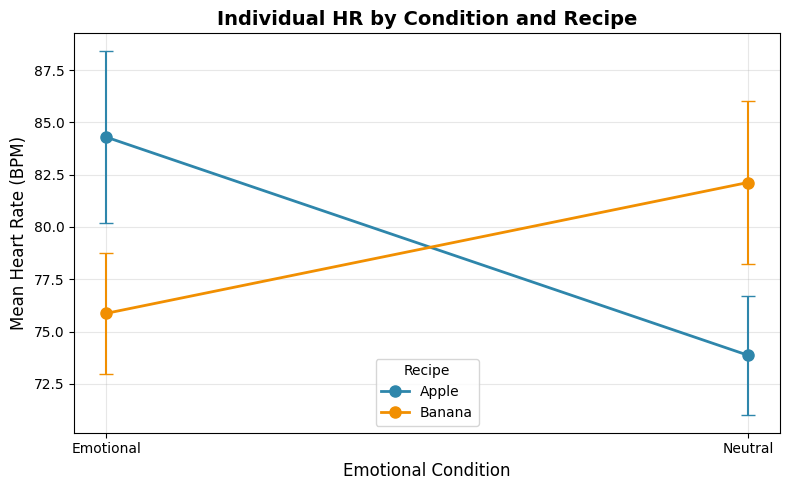

✓ Saved analysis2_individual_hr.png

ANALYSIS 3: SYNCHRONY CHANGE OVER TIME (SLOPE)

Sessions with windowed synchrony data: 37

Synchrony slope by condition (positive = increasing synchrony over time):
                  Mean Slope        SD   N
emotion   recipe                          
Emotional Apple     0.000173  0.000950   9
          Banana   -0.000409  0.000951   9
Neutral   Apple     0.000211  0.000923  10
          Banana   -0.000030  0.000213   9

ANOVA on synchrony slope:
                            sum_sq    df         F    PR(>F)  partial_eta_sq
C(emotion)            3.864213e-07   1.0  0.566780  0.456879        0.016885
C(recipe)             1.529158e-06   1.0  2.242881  0.143736        0.063641
C(emotion):C(recipe)  2.682785e-07   1.0  0.393495  0.534784        0.011784
Residual              2.249884e-05  33.0       NaN       NaN        0.500000


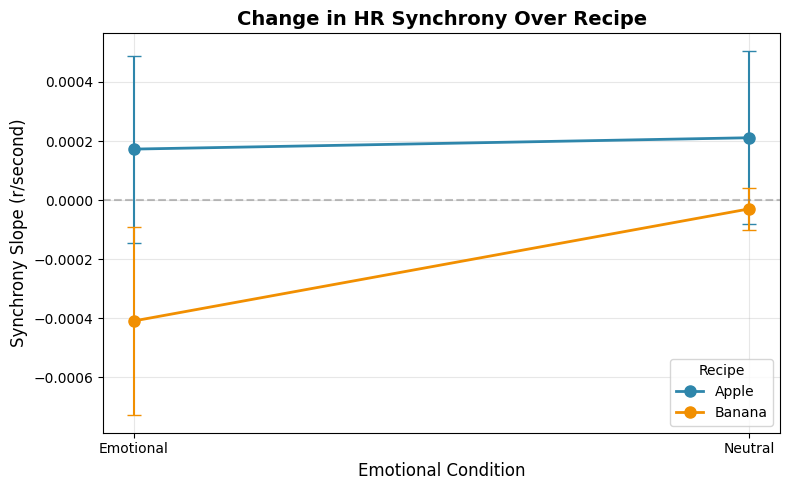

✓ Saved analysis3_synchrony_slope.png

ANALYSIS 4: ANCOVA — EMOTION EFFECT WITH COVARIATES

Phase sequence distribution:
phase_sequence
emotional_first    25
neutral_first      14
Name: count, dtype: int64

ANCOVA results (controlling for recipe and phase sequence):
                        sum_sq    df         F    PR(>F)  partial_eta_sq
C(emotion)            0.051757   1.0  3.324987  0.077036        0.089082
C(recipe)             0.139150   1.0  8.939255  0.005159        0.208184
C(phase_sequence)     0.007013   1.0  0.450513  0.506626        0.013077
C(emotion):C(recipe)  0.053373   1.0  3.428754  0.072771        0.091607
Residual              0.529250  34.0       NaN       NaN        0.500000

Partial Eta Squared:
  C(emotion): η²p = 0.089
  C(recipe): η²p = 0.208
  C(phase_sequence): η²p = 0.013
  C(emotion):C(recipe): η²p = 0.092

ANALYSIS 5: LEADER-FOLLOWER ANALYSIS

Sessions with lag data: 39

Leader distribution by condition:
     emotion       leader  n
0  Emotional     P1 lea

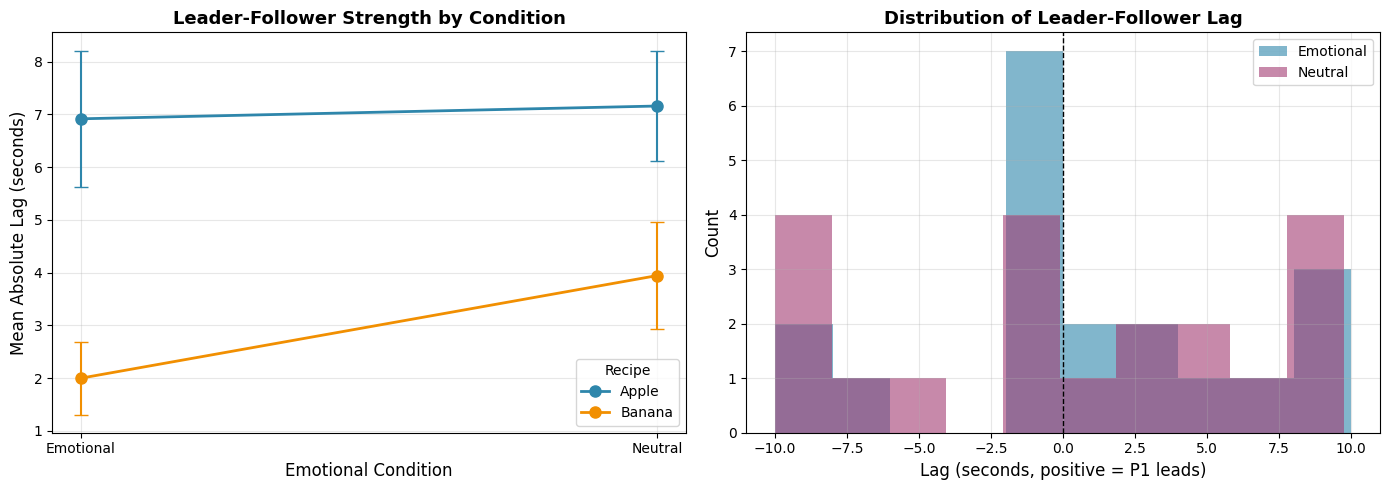

✓ Saved analysis5_leader_follower.png

✓ Full dataset saved → full_analysis_data.csv
✓ ANCOVA table saved → analysis4_ancova.csv

ALL ANALYSES COMPLETE


In [9]:
"""
Notebook 06 — Neutral vs Emotional Condition Analysis
======================================================
Compares HR synchrony, individual HR, synchrony slope, and leader-follower
dynamics between Emotional and Neutral cooking conditions.

Requires outputs from:
  - processed_data/           (metadata.json, HR CSVs)
  - ecg_hrv_results/          (ecg_hrv_results.json, hr_rpeak_*.csv, synchrony_rpeak_windowed.csv)
  - modular_synchrony_results/ (synchrony_overall.csv)   [optional]
  - COGS 402 Participants - Sheet.csv
"""

import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE          = Path("/Users/rachelsong/Desktop/Movesense")
participants_csv   = BASE / "COGS 402 Participants - Sheet.csv"
ecg_hrv_dir        = BASE / "ecg_hrv_results"
processed_data_dir = BASE / "processed_data"
modular_dir        = BASE / "modular_synchrony_results"
output_dir         = BASE  # save plots/CSVs here

# ── Load participants sheet ───────────────────────────────────────────────────
participants_df = pd.read_csv(participants_csv)
participants_df.columns = ['cohort', 'participant_id', 'sensor_id', 'condition', 'notes']

cohort_conditions    = {}
cohort_participants  = {}
cohort_phase_sequence = {}

for cohort, group in participants_df.groupby('cohort'):
    cohort_participants[cohort] = list(group['participant_id'].astype(int))
    cond_row = group[group['condition'].notna() & (group['condition'].str.strip() != '')]
    if not cond_row.empty:
        cond_str = str(cond_row.iloc[0]['condition']).strip()
        parts = [c.strip() for c in cond_str.split(',')]
        if len(parts) == 2:
            cohort_conditions[cohort]     = {'phase1': parts[0], 'phase2': parts[1]}
            cohort_phase_sequence[cohort] = 'emotional_first' if parts[0][0] == 'E' else 'neutral_first'

print(f"✓ Loaded {len(cohort_conditions)} cohorts with condition info")

# ── Load all session data ─────────────────────────────────────────────────────
records = []

for session_dir in sorted(ecg_hrv_dir.iterdir()):
    if not session_dir.is_dir():
        continue

    results_file  = session_dir / 'ecg_hrv_results.json'
    metadata_file = processed_data_dir / session_dir.name / 'metadata.json'

    if not results_file.exists() or not metadata_file.exists():
        print(f"  ⚠️  Skipping {session_dir.name} — missing results or metadata")
        continue

    with open(results_file)  as f: results  = json.load(f)
    with open(metadata_file) as f: metadata = json.load(f)

    sensor1 = str(metadata['sensor_1'])[-4:]
    sensor2 = str(metadata['sensor_2'])[-4:]
    cohort  = metadata.get('cohort')

    if not cohort or cohort not in cohort_conditions or cohort not in cohort_participants:
        print(f"  ⚠️  Skipping {session_dir.name} — cohort '{cohort}' not in participants sheet")
        continue

    ordered = cohort_participants[cohort]
    if len(ordered) != 4:
        print(f"  ⚠️  Skipping {cohort} — expected 4 participants, got {len(ordered)}")
        continue

    cohort_rows      = participants_df[participants_df['cohort'] == cohort]
    cohort_sensor_map = {str(int(r['sensor_id']))[-4:]: int(r['participant_id'])
                         for _, r in cohort_rows.iterrows()}

    if sensor1 not in cohort_sensor_map or sensor2 not in cohort_sensor_map:
        print(f"  ⚠️  Skipping {session_dir.name} — sensor IDs {sensor1}/{sensor2} not in cohort map")
        continue

    p1_id = cohort_sensor_map[sensor1]
    p2_id = cohort_sensor_map[sensor2]

    if p1_id not in ordered or p2_id not in ordered:
        continue

    positions = sorted([ordered.index(p1_id), ordered.index(p2_id)])

    if positions in [[0, 1], [2, 3]]:
        phase          = 1
        condition_code = cohort_conditions[cohort]['phase1']
    elif positions in [[0, 2], [1, 3]]:
        phase          = 2
        condition_code = cohort_conditions[cohort]['phase2']
    else:
        print(f"  ⚠️  Skipping {session_dir.name} — unexpected participant pairing {positions}")
        continue

    emotion        = 'Emotional' if condition_code[0] == 'E' else 'Neutral'
    recipe         = 'Apple'     if condition_code[1] == 'A' else 'Banana'
    phase_sequence = cohort_phase_sequence[cohort]

    r        = results['overall_r']
    fisher_z = np.arctanh(np.clip(r, -0.9999, 0.9999))

    # ── Individual HR ────────────────────────────────────────
    hr_p1_file = session_dir / 'hr_rpeak_Participant_A.csv'
    hr_p2_file = session_dir / 'hr_rpeak_Participant_B.csv'

    mean_hr_p1 = mean_hr_p2 = hr_slope_p1 = hr_slope_p2 = np.nan

    if hr_p1_file.exists() and hr_p2_file.exists():
        hr_p1 = pd.read_csv(hr_p1_file)
        hr_p2 = pd.read_csv(hr_p2_file)
        mean_hr_p1 = hr_p1['HeartRate'].mean()
        mean_hr_p2 = hr_p2['HeartRate'].mean()
        if len(hr_p1) > 1:
            hr_slope_p1 = np.polyfit(hr_p1['Time'], hr_p1['HeartRate'], 1)[0]
        if len(hr_p2) > 1:
            hr_slope_p2 = np.polyfit(hr_p2['Time'], hr_p2['HeartRate'], 1)[0]

    # ── Windowed synchrony slope ─────────────────────────────
    windowed_file = session_dir / 'synchrony_rpeak_windowed.csv'
    sync_slope    = np.nan
    if windowed_file.exists():
        windowed = pd.read_csv(windowed_file)
        if len(windowed) > 1:
            sync_slope = np.polyfit(windowed['Time'], windowed['Correlation'], 1)[0]

    # ── Cross-correlation lag (from modular notebook) ────────
    modular_file = modular_dir / session_dir.name / 'synchrony_overall.csv'
    xcorr_lag    = np.nan
    if modular_file.exists():
        modular = pd.read_csv(modular_file)
        if 'xcorr_lag_s' in modular.columns:
            xcorr_lag = float(modular['xcorr_lag_s'].values[0])

    records.append({
        'session':          session_dir.name,
        'cohort':           cohort,
        'participant_1_id': p1_id,
        'participant_2_id': p2_id,
        'phase':            phase,
        'phase_sequence':   phase_sequence,
        'condition_code':   condition_code,
        'emotion':          emotion,
        'recipe':           recipe,
        'overall_r':        r,
        'fisher_z':         fisher_z,
        'mean_hr_p1':       mean_hr_p1,
        'mean_hr_p2':       mean_hr_p2,
        'hr_slope_p1':      hr_slope_p1,
        'hr_slope_p2':      hr_slope_p2,
        'sync_slope':       sync_slope,
        'xcorr_lag':        xcorr_lag,
        'duration_seconds': results['duration_seconds'],
    })

df = pd.DataFrame(records)
print(f"\n✓ Loaded {len(df)} sessions")
print(f"\nCondition breakdown:")
print(df.groupby(['emotion', 'recipe', 'phase_sequence']).size().reset_index(name='n').to_string(index=False))

# Quick check
all_p_ids = set(df['participant_1_id'].tolist() + df['participant_2_id'].tolist())
print(f"\nUnique participants in analysis : {len(all_p_ids)}")
print(f"Total dyads                     : {len(df)}")

colors = {'Apple': '#2E86AB', 'Banana': '#F18F01'}

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1: Overall HR synchrony — Emotional vs Neutral
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("ANALYSIS 1: HR SYNCHRONY (Fisher Z) — EMOTIONAL vs NEUTRAL")
print(f"{'='*60}")

sync_desc = df.groupby(['emotion', 'recipe'])['fisher_z'].agg(['mean', 'std', 'count'])
sync_desc.columns = ['Mean Fisher Z', 'SD', 'N']
print("\nMean synchrony (Fisher Z) by condition:")
print(sync_desc)

model_sync = ols('fisher_z ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=df).fit()
anova_sync = anova_lm(model_sync, typ=2)
ss_res = anova_sync.loc['Residual', 'sum_sq']
anova_sync['partial_eta_sq'] = anova_sync['sum_sq'] / (anova_sync['sum_sq'] + ss_res)
print("\nANOVA on HR synchrony:")
print(anova_sync)

fig, ax = plt.subplots(figsize=(8, 5))
for recipe in ['Apple', 'Banana']:
    subset = df[df['recipe'] == recipe].groupby('emotion')['fisher_z'].agg(['mean', 'sem'])
    ax.plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
            color=colors[recipe], label=recipe)
    ax.errorbar(subset.index, subset['mean'], yerr=subset['sem'],
                fmt='none', color=colors[recipe], capsize=5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Emotional Condition', fontsize=12)
ax.set_ylabel('HR Synchrony (Fisher Z)', fontsize=12)
ax.set_title('HR Synchrony by Condition and Recipe', fontsize=14, fontweight='bold')
ax.legend(title='Recipe')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'analysis1_hr_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved analysis1_hr_synchrony.png")

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2: Individual HR — Emotional vs Neutral
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("ANALYSIS 2: INDIVIDUAL HR — EMOTIONAL vs NEUTRAL")
print(f"{'='*60}")

hr_desc = df.groupby(['emotion', 'recipe'])[['mean_hr_p1', 'mean_hr_p2']].mean()
print("\nMean HR by condition:")
print(hr_desc)

# Stack P1 and P2 into long format
hr_long = pd.concat([
    df[['emotion', 'recipe', 'phase_sequence', 'mean_hr_p1']].rename(columns={'mean_hr_p1': 'mean_hr'}),
    df[['emotion', 'recipe', 'phase_sequence', 'mean_hr_p2']].rename(columns={'mean_hr_p2': 'mean_hr'}),
]).dropna()

model_hr = ols('mean_hr ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=hr_long).fit()
anova_hr = anova_lm(model_hr, typ=2)
ss_res = anova_hr.loc['Residual', 'sum_sq']
anova_hr['partial_eta_sq'] = anova_hr['sum_sq'] / (anova_hr['sum_sq'] + ss_res)
print("\nANOVA on individual mean HR:")
print(anova_hr)

fig, ax = plt.subplots(figsize=(8, 5))
for recipe in ['Apple', 'Banana']:
    subset = hr_long[hr_long['recipe'] == recipe].groupby('emotion')['mean_hr'].agg(['mean', 'sem'])
    ax.plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
            color=colors[recipe], label=recipe)
    ax.errorbar(subset.index, subset['mean'], yerr=subset['sem'],
                fmt='none', color=colors[recipe], capsize=5)
ax.set_xlabel('Emotional Condition', fontsize=12)
ax.set_ylabel('Mean Heart Rate (BPM)', fontsize=12)
ax.set_title('Individual HR by Condition and Recipe', fontsize=14, fontweight='bold')
ax.legend(title='Recipe')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'analysis2_individual_hr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved analysis2_individual_hr.png")

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 3: Synchrony slope over time — Emotional vs Neutral
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("ANALYSIS 3: SYNCHRONY CHANGE OVER TIME (SLOPE)")
print(f"{'='*60}")

sync_slope_df = df.dropna(subset=['sync_slope'])
print(f"\nSessions with windowed synchrony data: {len(sync_slope_df)}")

if len(sync_slope_df) > 0:
    slope_desc = sync_slope_df.groupby(['emotion', 'recipe'])['sync_slope'].agg(['mean', 'std', 'count'])
    slope_desc.columns = ['Mean Slope', 'SD', 'N']
    print("\nSynchrony slope by condition (positive = increasing synchrony over time):")
    print(slope_desc)

    model_slope = ols('sync_slope ~ C(emotion) + C(recipe) + C(emotion):C(recipe)',
                      data=sync_slope_df).fit()
    anova_slope = anova_lm(model_slope, typ=2)
    ss_res = anova_slope.loc['Residual', 'sum_sq']
    anova_slope['partial_eta_sq'] = anova_slope['sum_sq'] / (anova_slope['sum_sq'] + ss_res)
    print("\nANOVA on synchrony slope:")
    print(anova_slope)

    fig, ax = plt.subplots(figsize=(8, 5))
    for recipe in ['Apple', 'Banana']:
        subset = sync_slope_df[sync_slope_df['recipe'] == recipe].groupby('emotion')['sync_slope'].agg(['mean', 'sem'])
        ax.plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
                color=colors[recipe], label=recipe)
        ax.errorbar(subset.index, subset['mean'], yerr=subset['sem'],
                    fmt='none', color=colors[recipe], capsize=5)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Emotional Condition', fontsize=12)
    ax.set_ylabel('Synchrony Slope (r/second)', fontsize=12)
    ax.set_title('Change in HR Synchrony Over Recipe', fontsize=14, fontweight='bold')
    ax.legend(title='Recipe')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'analysis3_synchrony_slope.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved analysis3_synchrony_slope.png")
else:
    print("⚠️  No windowed synchrony data found — skipping slope analysis")

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 4: ANCOVA — emotion effect controlling for recipe + phase order
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("ANALYSIS 4: ANCOVA — EMOTION EFFECT WITH COVARIATES")
print(f"{'='*60}")

print("\nPhase sequence distribution:")
print(df['phase_sequence'].value_counts())

model_ancova = ols(
    'fisher_z ~ C(emotion) + C(recipe) + C(phase_sequence) + C(emotion):C(recipe)',
    data=df
).fit()
anova_ancova = anova_lm(model_ancova, typ=2)
ss_res = anova_ancova.loc['Residual', 'sum_sq']
anova_ancova['partial_eta_sq'] = anova_ancova['sum_sq'] / (anova_ancova['sum_sq'] + ss_res)
print("\nANCOVA results (controlling for recipe and phase sequence):")
print(anova_ancova)
print("\nPartial Eta Squared:")
for idx in anova_ancova.index[:-1]:
    print(f"  {idx}: η²p = {anova_ancova.loc[idx, 'partial_eta_sq']:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 5: Leader-follower — Emotional vs Neutral
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("ANALYSIS 5: LEADER-FOLLOWER ANALYSIS")
print(f"{'='*60}")

lf_df = df.dropna(subset=['xcorr_lag']).copy()
print(f"\nSessions with lag data: {len(lf_df)}")

if len(lf_df) > 0:
    lf_df['abs_lag'] = lf_df['xcorr_lag'].abs()
    lf_df['leader']  = lf_df['xcorr_lag'].apply(
        lambda x: 'P1 leads' if x > 1 else ('P2 leads' if x < -1 else 'Synchronous')
    )

    print("\nLeader distribution by condition:")
    print(lf_df.groupby(['emotion', 'leader']).size().reset_index(name='n'))

    print("\nMean absolute lag by condition (higher = stronger leader-follower):")
    lag_desc = lf_df.groupby(['emotion', 'recipe'])['abs_lag'].agg(['mean', 'std', 'count'])
    lag_desc.columns = ['Mean |Lag| (s)', 'SD', 'N']
    print(lag_desc)

    model_lag = ols('abs_lag ~ C(emotion) + C(recipe) + C(emotion):C(recipe)', data=lf_df).fit()
    anova_lag = anova_lm(model_lag, typ=2)
    ss_res = anova_lag.loc['Residual', 'sum_sq']
    anova_lag['partial_eta_sq'] = anova_lag['sum_sq'] / (anova_lag['sum_sq'] + ss_res)
    print("\nANOVA on absolute lag:")
    print(anova_lag)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for recipe in ['Apple', 'Banana']:
        subset = lf_df[lf_df['recipe'] == recipe].groupby('emotion')['abs_lag'].agg(['mean', 'sem'])
        axes[0].plot(subset.index, subset['mean'], 'o-', linewidth=2, markersize=8,
                     color=colors[recipe], label=recipe)
        axes[0].errorbar(subset.index, subset['mean'], yerr=subset['sem'],
                         fmt='none', color=colors[recipe], capsize=5)
    axes[0].set_xlabel('Emotional Condition', fontsize=12)
    axes[0].set_ylabel('Mean Absolute Lag (seconds)', fontsize=12)
    axes[0].set_title('Leader-Follower Strength by Condition', fontsize=13, fontweight='bold')
    axes[0].legend(title='Recipe')
    axes[0].grid(True, alpha=0.3)

    for emotion in ['Emotional', 'Neutral']:
        subset = lf_df[lf_df['emotion'] == emotion]['xcorr_lag']
        axes[1].hist(subset, bins=10, alpha=0.6, label=emotion,
                     color='#2E86AB' if emotion == 'Emotional' else '#A23B72')
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Lag (seconds, positive = P1 leads)', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Distribution of Leader-Follower Lag', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_dir / 'analysis5_leader_follower.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved analysis5_leader_follower.png")
else:
    print("⚠️  No lag data found — run Notebook 4 first to generate modular synchrony results")

# ═══════════════════════════════════════════════════════════════════════════════
# Save full dataset + ANOVA tables
# ═══════════════════════════════════════════════════════════════════════════════
df.to_csv(output_dir / 'full_analysis_data.csv', index=False)
anova_ancova.to_csv(output_dir / 'analysis4_ancova.csv')
print(f"\n✓ Full dataset saved → full_analysis_data.csv")
print(f"✓ ANCOVA table saved → analysis4_ancova.csv")
print(f"\n{'='*60}")
print("ALL ANALYSES COMPLETE")
print(f"{'='*60}")

In [10]:
all_p_ids = set(df['participant_1_id'].tolist() + df['participant_2_id'].tolist())
print(f"Unique participants in analysis: {len(all_p_ids)}")
print(f"Participant IDs: {sorted(all_p_ids)}")
print(f"Total dyads: {len(df)}")

Unique participants in analysis: 43
Participant IDs: [5, 6, 7, 8, 9, 10, 11, 12, 17, 18, 19, 20, 29, 30, 31, 32, 45, 46, 47, 48, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 77, 78, 79, 80]
Total dyads: 39


In [11]:
all_p_ids = set(df['participant_1_id'].tolist() + df['participant_2_id'].tolist())
print("Participants IN the analysis:", sorted(all_p_ids))

Participants IN the analysis: [5, 6, 7, 8, 9, 10, 11, 12, 17, 18, 19, 20, 29, 30, 31, 32, 45, 46, 47, 48, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 77, 78, 79, 80]


In [14]:
from pathlib import Path

processed = Path("/Users/rachelsong/Desktop/Movesense/processed_data")
ecg = Path("/Users/rachelsong/Desktop/Movesense/ecg_hrv_results")

print("=== IN processed_data ===")
for f in sorted(processed.iterdir()):
    if f.is_dir(): print(f.name)

print("\n=== IN ecg_hrv_results ===")
for f in sorted(ecg.iterdir()):
    if f.is_dir(): print(f.name)

=== IN processed_data ===
2025_11_28-22_39_22
2025_11_28-22_42_49
2025_11_28-23_07_21
2025_11_28-23_07_45
2025_12_01-22_31_58
2025_12_01-22_37_05
2025_12_01-23_08_42
2025_12_01-23_08_47
2025_12_16-22_00_52
2025_12_16-22_01_30
2025_12_16-22_29_50
2025_12_16-22_32_49
2025_12_19-19_20_59
2025_12_19-19_21_15
2025_12_19-19_41_02
2025_12_19-19_42_49
2026_02_09-23_59_21
2026_02_09-23_59_40
2026_02_10-00_17_30
2026_02_10-00_17_33
2026_02_14-00_23_15
2026_02_14-00_59_57
2026_02_14-01_00_21
2026_02_23-23_44_00
2026_02_24-00_18_07
2026_02_24-00_18_47
2026_02_25-22_07_47
2026_02_25-22_29_36
2026_02_26-00_15_15
2026_02_26-00_15_27
2026_02_26-00_39_41
2026_02_27-22_45_12
2026_02_27-22_45_47
2026_02_27-23_08_22
2026_02_27-23_09_25
2026_03_04-21_29_39
2026_03_04-21_31_07
2026_03_04-21_51_52
2026_03_04-21_54_00

=== IN ecg_hrv_results ===
2025_11_28-22_39_22
2025_11_28-22_42_49
2025_11_28-23_07_21
2025_11_28-23_07_45
2025_12_01-22_31_58
2025_12_01-22_37_05
2025_12_01-23_08_42
2025_12_01-23_08_47
2025_1